# Flight Dataset — Outlier Analysis
Saint-Exupery Airport | `database.db`

## 1. Import libraries

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import os, warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
print('Libraries ready')

Libraries ready


In [2]:
OUT_DIR = Path(os.getcwd()) / 'outputs' / 'outlier_analysis'
OUT_DIR.mkdir(parents=True, exist_ok=True)
print('Output folder:', OUT_DIR)

Output folder: c:\Users\ACER\Documents\GitHub\master-minds-challenge\outputs\outlier_analysis


## 2. Load data

In [3]:
_here = Path(os.getcwd())
DB_PATH = _here / 'database.db'
if not DB_PATH.exists():
    DB_PATH = _here / 'Procedure_data' / 'insa' / 'database.db'

conn = sqlite3.connect(str(DB_PATH))
df = pd.read_sql_query('SELECT * FROM mouvements_aero_insa', conn)
conn.close()

df['LTScheduledDatetime'] = pd.to_datetime(df['LTScheduledDatetime'], errors='coerce')

NUM_COLS = ['NbPaxTotal', 'DelayMainReasonDuration', 'TaxiDurationMinutes', 'TurnsBlockTimeMinutes']
for col in NUM_COLS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'Loaded {len(df):,} rows')

Loaded 364,623 rows


## 3. IQR-based outlier detection

In [4]:
def iqr_summary(series, label=''):
    s = series.dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    out = s[(s < lo) | (s > hi)]
    print(f'{label or series.name:<30} Q1={Q1:.1f}  Q3={Q3:.1f}  IQR={IQR:.1f}  '
          f'fence=[{lo:.1f}, {hi:.1f}]  outliers={len(out):,} ({len(out)/len(s)*100:.1f}%)')
    return lo, hi

print('IQR Outlier Summary')
print('-' * 90)
iqr_bounds = {}
for col in NUM_COLS:
    if col in df.columns:
        lo, hi = iqr_summary(df[col])
        iqr_bounds[col] = (lo, hi)

IQR Outlier Summary
------------------------------------------------------------------------------------------
NbPaxTotal                     Q1=62.0  Q3=156.0  IQR=94.0  fence=[-79.0, 297.0]  outliers=1,042 (0.3%)
DelayMainReasonDuration        Q1=5.0  Q3=27.0  IQR=22.0  fence=[-28.0, 60.0]  outliers=4,434 (8.4%)
TaxiDurationMinutes            Q1=-10.0  Q3=5.0  IQR=15.0  fence=[-32.5, 27.5]  outliers=218 (0.1%)
TurnsBlockTimeMinutes          Q1=48.0  Q3=109.0  IQR=61.0  fence=[-43.5, 200.5]  outliers=20,738 (20.2%)


## 4. Boxplots — numeric columns

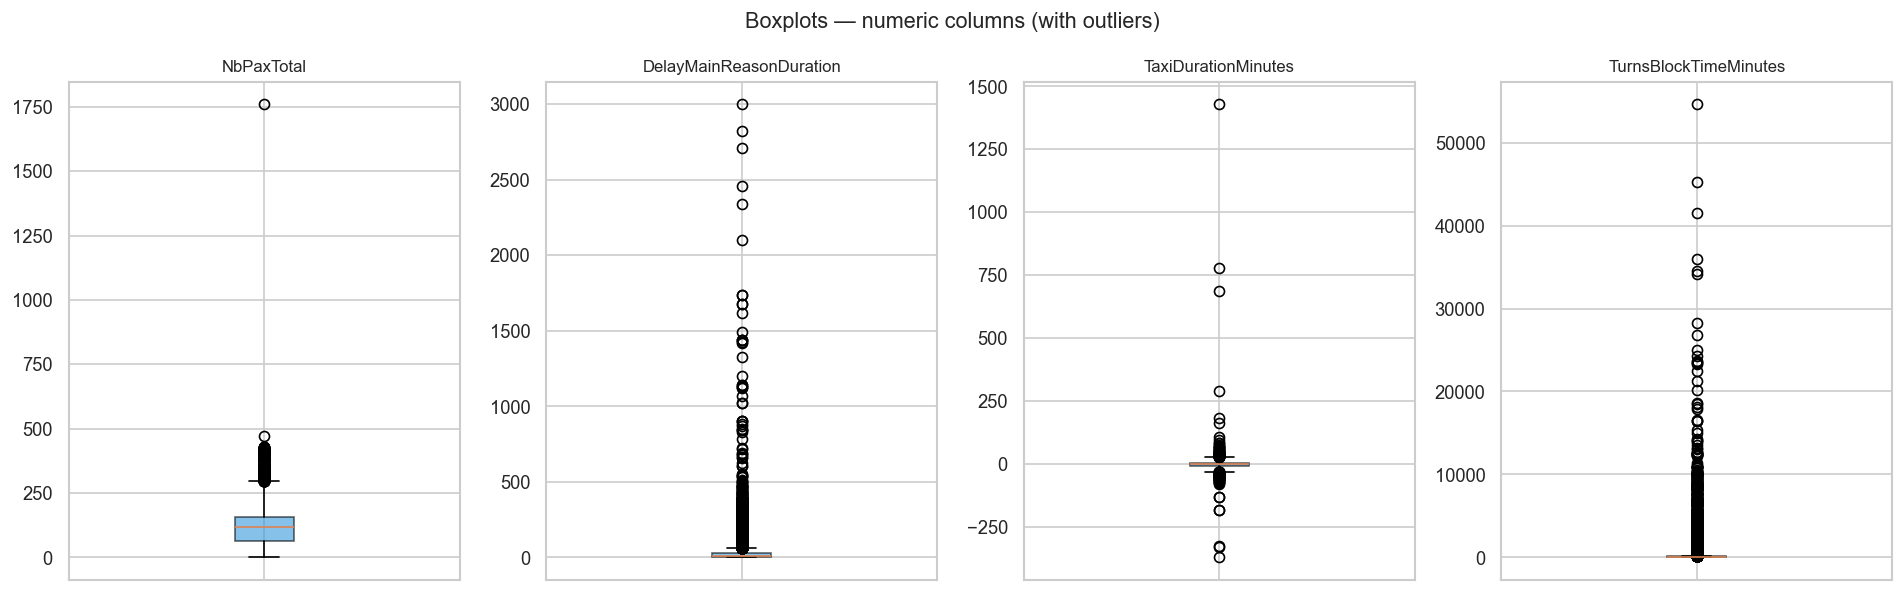

In [5]:
valid_cols = [c for c in NUM_COLS if c in df.columns]
n = len(valid_cols)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 5))
if n == 1:
    axes = [axes]

for ax, col in zip(axes, valid_cols):
    s = df[col].dropna()
    ax.boxplot(s, vert=True, patch_artist=True,
               boxprops=dict(facecolor='#3498db', alpha=0.6))
    ax.set_title(col, fontsize=10)
    ax.set_xticklabels([''])

fig.suptitle('Boxplots — numeric columns (with outliers)', fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / '01_boxplots.png', bbox_inches='tight', dpi=150)
plt.show()

## 5. Z-score analysis

In [6]:
print('Z-score outliers (|z| > 3)\n' + '-' * 50)
for col in valid_cols:
    s = df[col].dropna()
    z = np.abs(stats.zscore(s))
    extreme = (z > 3).sum()
    print(f'{col:<30} {extreme:,} rows  ({extreme/len(s)*100:.2f}%)')

Z-score outliers (|z| > 3)
--------------------------------------------------
NbPaxTotal                     1,010 rows  (0.32%)
DelayMainReasonDuration        472 rows  (0.89%)
TaxiDurationMinutes            364 rows  (0.12%)
TurnsBlockTimeMinutes          1,084 rows  (1.06%)


## 6. NbPaxTotal — distribution & skewness

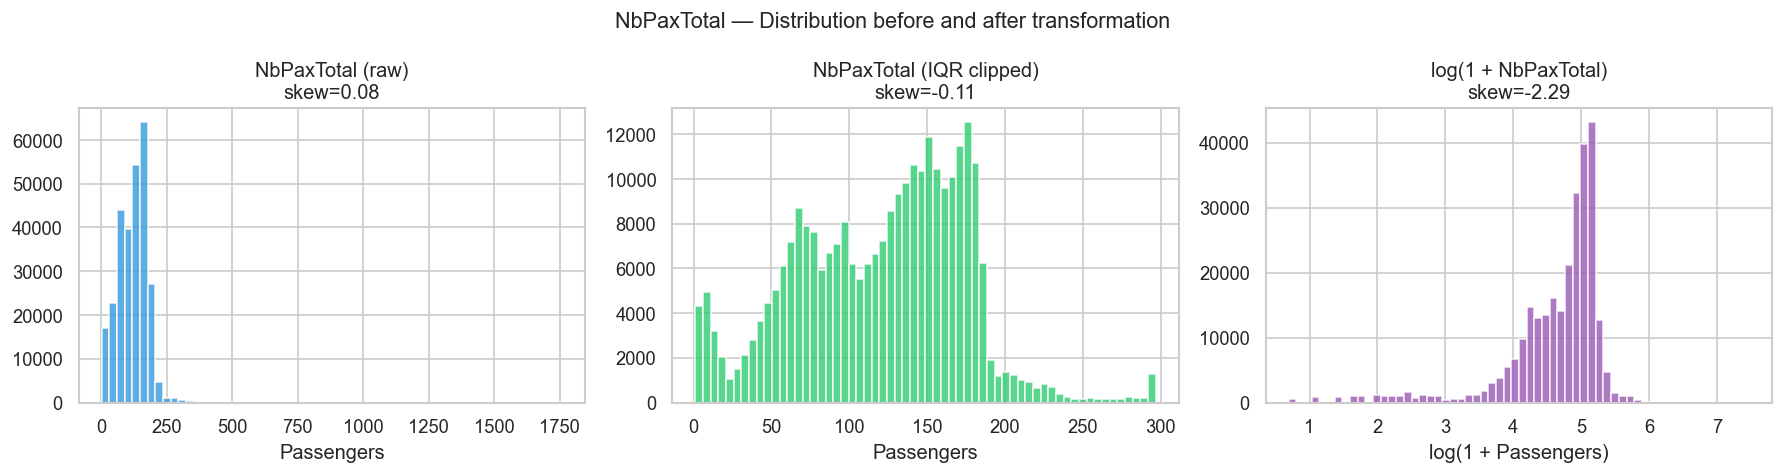

In [7]:
pax = df['NbPaxTotal'].dropna()
pax_pos = pax[pax > 0]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Raw distribution
axes[0].hist(pax_pos, bins=60, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].set_title(f'NbPaxTotal (raw)\nskew={pax_pos.skew():.2f}')
axes[0].set_xlabel('Passengers')

# Clipped (IQR)
lo, hi = iqr_bounds.get('NbPaxTotal', (pax_pos.min(), pax_pos.max()))
pax_clip = pax_pos.clip(lo, hi)
axes[1].hist(pax_clip, bins=60, color='#2ecc71', edgecolor='white', alpha=0.8)
axes[1].set_title(f'NbPaxTotal (IQR clipped)\nskew={pax_clip.skew():.2f}')
axes[1].set_xlabel('Passengers')

# Log transform
pax_log = np.log1p(pax_pos)
axes[2].hist(pax_log, bins=60, color='#9b59b6', edgecolor='white', alpha=0.8)
axes[2].set_title(f'log(1 + NbPaxTotal)\nskew={pax_log.skew():.2f}')
axes[2].set_xlabel('log(1 + Passengers)')

plt.suptitle('NbPaxTotal — Distribution before and after transformation', fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / '02_nbpax_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

## 7. Outlier rows — closest look

In [8]:
if 'NbPaxTotal' in iqr_bounds:
    lo, hi = iqr_bounds['NbPaxTotal']
    outlier_mask = (df['NbPaxTotal'] < lo) | (df['NbPaxTotal'] > hi)
    print(f'Outlier rows by IQR (NbPaxTotal): {outlier_mask.sum():,}')

    cols_show = ['LTScheduledDatetime', 'airlineOACICode', 'IdAircraftType',
                 'Terminal', 'Direction', 'NbPaxTotal']
    cols_show = [c for c in cols_show if c in df.columns]
    print(df.loc[outlier_mask, cols_show]
          .sort_values('NbPaxTotal', ascending=False)
          .head(20)
          .to_string(index=False))

Outlier rows by IQR (NbPaxTotal): 1,042
LTScheduledDatetime airlineOACICode IdAircraftType Terminal Direction  NbPaxTotal
2023-05-03 00:00:00             TVF            738   T1 Sat   Arrivée      1760.0
2025-03-11 08:45:00             FBU            351       T1   Arrivée       471.0
2025-02-22 14:40:00             UAE            77W       T1    Départ       428.0
2024-05-12 13:50:00             UAE            77W       T1   Arrivée       428.0
2025-02-22 12:50:00             UAE            77W       T1   Arrivée       428.0
2024-10-27 14:40:00             UAE            77W       T1    Départ       427.0
2025-02-23 14:40:00             UAE            77W       T1    Départ       426.0
2024-09-16 15:40:00             UAE            77W       T1    Départ       425.0
2024-10-27 12:50:00             UAE            77W       T1   Arrivée       425.0
2025-02-15 14:40:00             UAE            77W       T1    Départ       425.0
2024-10-18 15:40:00             UAE            77W       T

## 8. Summary

In [9]:
print('=' * 55)
print('OUTLIER ANALYSIS SUMMARY')
print('=' * 55)
for col in valid_cols:
    s = df[col].dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((s < lo) | (s > hi)).sum()
    z_out = (np.abs(stats.zscore(s)) > 3).sum()
    print(f'{col:<30} IQR outliers: {n_out:>5,} ({n_out/len(s)*100:4.1f}%)   Z>3: {z_out:>5,} ({z_out/len(s)*100:4.1f}%)')
print('=' * 55)
print(f'Recommendation: log-transform NbPaxTotal before regression.')
print(f'  Raw skew  : {pax_pos.skew():.3f}')
print(f'  Log skew  : {np.log1p(pax_pos).skew():.3f}')

OUTLIER ANALYSIS SUMMARY
NbPaxTotal                     IQR outliers: 1,042 ( 0.3%)   Z>3: 1,010 ( 0.3%)
DelayMainReasonDuration        IQR outliers: 4,434 ( 8.4%)   Z>3:   472 ( 0.9%)
TaxiDurationMinutes            IQR outliers:   218 ( 0.1%)   Z>3:   364 ( 0.1%)
TurnsBlockTimeMinutes          IQR outliers: 20,738 (20.2%)   Z>3: 1,084 ( 1.1%)
Recommendation: log-transform NbPaxTotal before regression.
  Raw skew  : 0.081
  Log skew  : -2.288
